In [37]:
## libraries to install ##
#!pip install seaborn pandas matplotlib numpy tabulate plotly

import os
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import numpy as np
from matplotlib.gridspec import GridSpec

from hbn.constants import Defaults  
from hbn.visualization import make_tables, visualize as vis

import plotly.io as pio
pio.renderers.default='notebook'

%load_ext autoreload
%autoreload 2

import warnings
warnings.filterwarnings('ignore')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [40]:
vis.plotting_style()

In [154]:
# Define diagnosis (and no diagnosis)
no_diagnosis = 'No Diagnosis Given'
diagnosis_old = 'Specific Learning Disorder with Impairment in Reading'
diagnosis_new =  'Reading Impairment'

# load data
df = pd.read_csv(os.path.join(Defaults.INTERIM_DIR, 'phenotypes', 'participant_train_test.csv'), engine='python')

# filter data for certain diagnoses
df['DX_Cat_Name'] = df['DX_Cat_Name'] \
                    .str.replace(diagnosis_old, diagnosis_new)

# reformat columns and vlaues
df['Diagnosis'] = df['DX_Cat_Name'] \
                .apply(lambda x: x if x in [no_diagnosis, diagnosis_new] else float("NaN"))
df = df.rename(columns={'PreInt_Demos_Fam,Child_Race_cat': 'Race'})

# add comorbidities of participants diagnosed with reading impairment
participants_diag_no_diag = df[~df['Diagnosis'].isna()]['Identifiers'].tolist()
df1 = df[df['Identifiers'].isin(participants_diag_no_diag)] \
    .groupby('Identifiers') \
    .apply(lambda x: sum(~x['DX_Cat_Name'].isna())-1) \
    .reset_index(name='number_of_comorbidites') \
    .merge(df, on='Identifiers')


# filter for diagnosis: 'Reading Impairment' and 'No Diagnosis Given'
diagnosis = df1[df1['Diagnosis']==diagnosis_new].reset_index(drop=True)
no_diagnosis = df1[df1['Diagnosis']==no_diagnosis].reset_index(drop=True)
df_filter = pd.concat([diagnosis, no_diagnosis])


## Table - Demographics

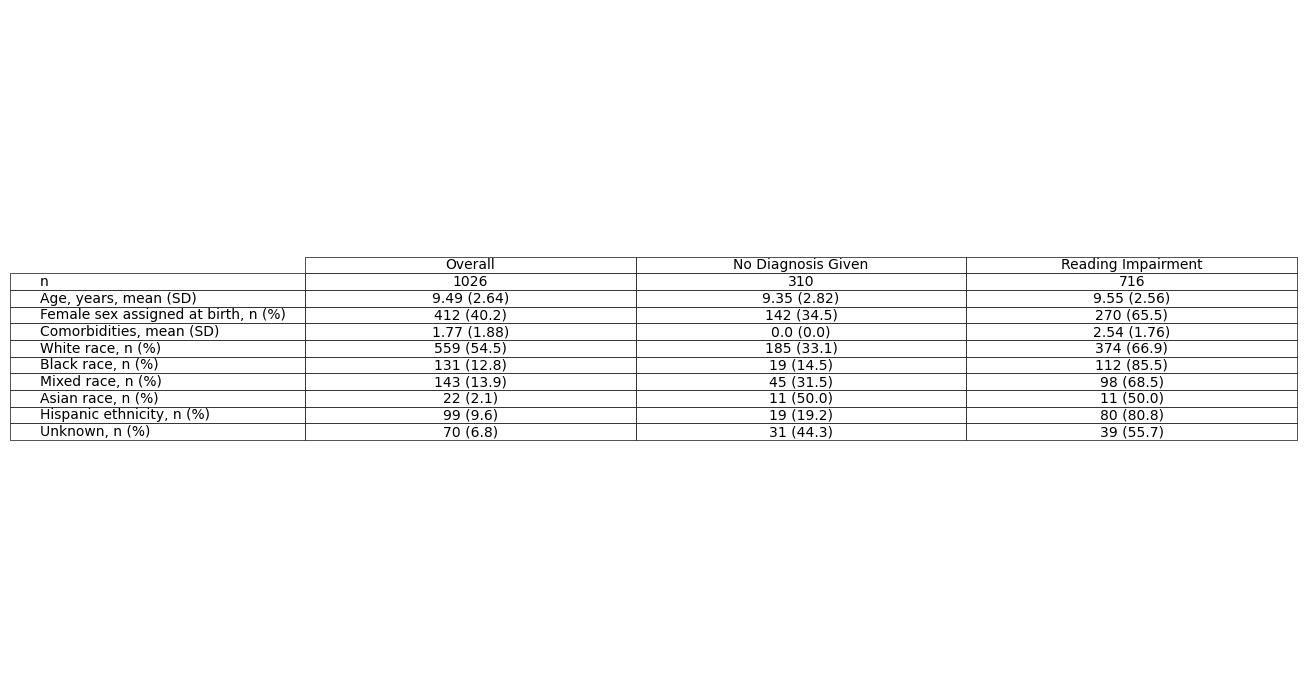

In [155]:
# mean and std for age
df_mean_std = make_tables.make_table_mean_std(df=df_filter,
                                          cols=['Age', 'number_of_comorbidites'],
                                          cols_new=['Age, years, mean (SD)', 'Comorbidities, mean (SD)'],
                                          )

# count and perc for race, ethnicity, gender (and count comorbiditiy)
vals = df_filter['Race'].unique().tolist()
cols = list(np.tile('Race', len(vals)))
vals.extend(['female'])
cols.extend(['Sex'])

# make table count
df_count = make_tables.make_table_count(df=df_filter, cols=cols, vals=vals)

# concat dataframes
df_concat = pd.concat([df_mean_std, df_count]).set_index('Demographics')

# rearrange the rows
desired_order = ['n', 'Age, years, mean (SD)', 'Female sex assigned at birth, n (%)',
                 'Comorbidities, mean (SD)', 'White race, n (%)', 'Black race, n (%)', 'Mixed race, n (%)',
                 'Asian race, n (%)', 'Hispanic ethnicity, n (%)', 'Unknown, n (%)'
                ]

df_full = df_concat.iloc[df_concat.index.get_indexer(desired_order)]

# save to file
df_full.to_csv(os.path.join(Defaults.PROCESSED_FIG_DIR, 'table_demos.csv'), index=False)

# # save to png
make_tables.make_table_png(df=df_full, outpath=os.path.join(Defaults.FIG_DIR, 'table_demos.png'))




## Figures - Demographics

<Figure size 1280x880 with 0 Axes>

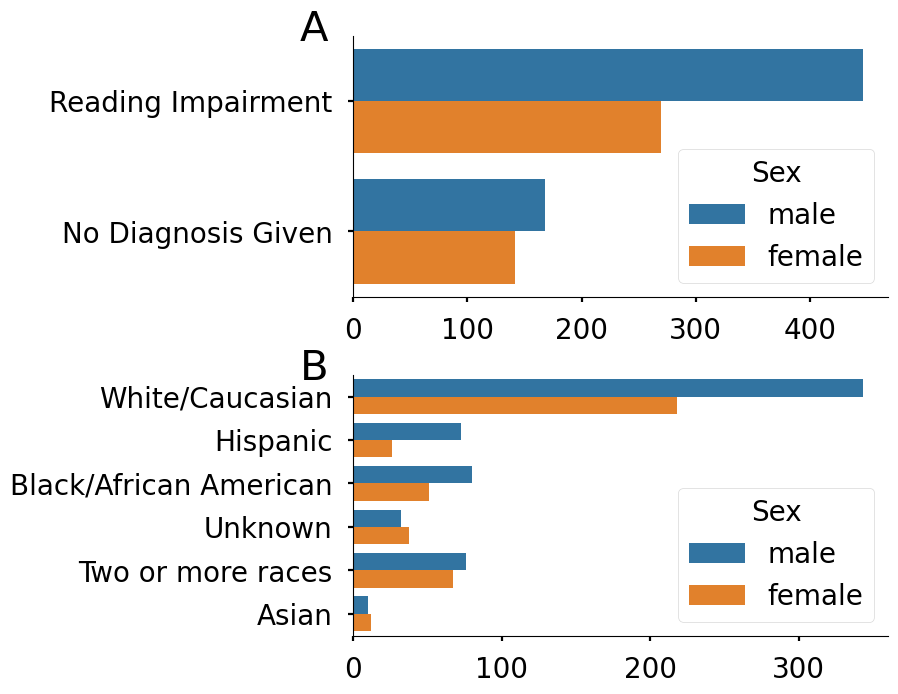

In [45]:
plt.clf()
#plotting_style()
x_pos = -0.1
y_pos = 1.1
labelsize = 30

fig = plt.figure(figsize=(2,3))
gs = GridSpec(2, 1, figure=fig)

ax = fig.add_subplot(gs[0,0])
ax = sns.countplot(data=df_filter, y='Diagnosis', hue='Sex', ax=ax)
ax.set_ylabel('')
ax.set_xlabel('')
# ax.set_title('Participant count across diagnoses')
ax.text(x_pos, y_pos, 'A', transform=ax.transAxes, fontsize=labelsize, verticalalignment='top')
ax.legend_.set_title('Sex')

ax = fig.add_subplot(gs[1,0])
ax = sns.countplot(data=df_filter, y='Race', hue='Sex', ax=ax)
ax.set_xlabel('')
ax.set_ylabel('')
# ax.set_title('Participant ages across primary diagnoses')
ax.text(x_pos, y_pos, 'B', transform=ax.transAxes, fontsize=labelsize, verticalalignment='top')
ax.legend_.set_title('Sex')
sns.despine()

plt.subplots_adjust(left=0.125, bottom=0.001, right=2.8, top=2.0, wspace=.2, hspace=.3)


In [44]:
## do breakdown by sex and early - emerging - fluent readers